# Week 3 – Day 2: Training Artificial Neural Networks
## How Neural Networks Learn - Full Notebook & Technical Report




## Table of Contents

1. [Learning Process in ANN](#sec1)
2. [Loss Functions](#sec2)
   - Regression losses
   - Classification losses
   - Task 1 - Implement Loss Functions from Scratch (NumPy)
   - Task 2 - Visualize Loss Functions
3. [Gradient Descent](#sec3)
   - Variants
   - Task 3 - Implement Gradient Descent on a Simple Regression Problem
4. [Backpropagation](#sec4)
5. [Optimizers](#sec5)
   - Task 4 - Train an ANN with TensorFlow/Keras (SGD vs Adam)
6. [Hyperparameter Effects](#sec6)
   - Task 5 - Hyperparameter Experiments
7. [Evaluation Visualizations](#sec7)
   - Task 6 - Loss/Accuracy Curves, Confusion Matrix, ROC, Precision–Recall
8. [Discussion & Experimental Results](#sec8)
9. [Research Task - Optimizer Comparison Papers](#sec9)
   - Paper 1 - A Comparison of Optimization Algorithms for Deep Learning (Soydaner, 2020)
   - Paper 2 - An Analysis of Optimizer Choice on Energy Efficiency and Performance (Almog, 2025)
   - Paper 3 - Comparative Study of Deep Learning Optimizers (2025, IJISRT)
   - Cross-paper synthesis
10. [Conclusion](#sec10)
11. [References](#sec-ref)




<a id="sec1"></a>
## 1. Learning Process in ANN

A neural network learns through a repeating cycle of five steps:

1. **Prediction** - a forward pass computes an output ŷ from the current weights.
2. **Error** - ŷ is compared against the true label/value y.
3. **Cost Function** - errors across the batch/training set are aggregated into a single scalar J(θ) summarizing "how wrong" the network currently is.
4. **Weight Update** - gradients of J with respect to every weight/bias are computed and used to nudge parameters toward lower cost.
5. **Learning Cycle** - steps 1–4 repeat for every mini-batch, every epoch, until the cost stops meaningfully improving.

```
   ┌──────────────┐   ┌──────────────┐   ┌──────────────┐   ┌──────────────────┐
   │ Forward Pass │──▶│ Compute Error│──▶│ Cost Function│──▶│ Backprop & Update│
   │  compute ŷ   │   │    ŷ − y     │   │    J(θ)      │   │  θ ← θ − η·∇J    │
   └──────────────┘   └──────────────┘   └──────────────┘   └─────────┬────────┘
          ▲                                                            │
          └────────────────────  repeat every batch / epoch  ─────────┘
```

This is the training loop underlying essentially all deep learning frameworks
(`model.fit()` in Keras, or the explicit `for epoch in range(...):` loop in PyTorch).


<a id="sec2"></a>
## 2. Loss Functions

The loss function defines what "error" means numerically, and its gradient drives learning.

### Regression losses

| Loss | Formula | Property |
|---|---|---|
| MAE | mean( \|y − ŷ\| ) | Robust to outliers; constant gradient magnitude |
| MSE | mean( (y − ŷ)² ) | Penalizes large errors heavily; smooth everywhere |
| RMSE | √MSE | Same units as target - easier to interpret |
| Huber | quadratic near 0, linear beyond δ | Combines MSE's smoothness with MAE's robustness |

### Classification losses

| Loss | Use case |
|---|---|
| Binary Cross-Entropy | Two-class problems with a sigmoid output |
| Categorical Cross-Entropy | Multi-class problems, one-hot labels, softmax output |
| Sparse Categorical Cross-Entropy | Same as above, integer labels instead of one-hot |

**Selection guidance:** use MAE/Huber when outliers are common; use MSE/RMSE to penalize large errors strongly; use cross-entropy variants for classification, choosing "sparse" purely for label-encoding convenience.

### Task 1 - Implement Loss Functions from Scratch (NumPy)

Implements MAE, MSE, RMSE, Huber, Binary Cross-Entropy, Categorical Cross-Entropy, and
Sparse Categorical Cross-Entropy using only NumPy, validated against scikit-learn.

In [1]:
"""
Task 1 - Implement loss functions from scratch using NumPy.

Implements:
    - Mean Absolute Error (MAE)
    - Mean Squared Error (MSE)
    - Binary Cross Entropy (BCE)
    - Categorical Cross Entropy (CCE)

Each function is validated against a small worked example and, where
available, cross-checked against scikit-learn's reference implementation.
"""

import numpy as np


def mae(y_true, y_pred):
    """Mean Absolute Error: average of |y_true - y_pred|."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def mse(y_true, y_pred):
    """Mean Squared Error: average of (y_true - y_pred)^2."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    """Root Mean Squared Error: sqrt(MSE)."""
    return np.sqrt(mse(y_true, y_pred))


def huber(y_true, y_pred, delta=1.0):
    """Huber loss: quadratic for small errors, linear for large errors."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    error = y_true - y_pred
    small = np.abs(error) <= delta
    squared_term = 0.5 * error ** 2
    linear_term = delta * (np.abs(error) - 0.5 * delta)
    return np.mean(np.where(small, squared_term, linear_term))


def binary_cross_entropy(y_true, y_pred, eps=1e-12):
    """Binary Cross Entropy for two-class classification."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def categorical_cross_entropy(y_true_onehot, y_pred, eps=1e-12):
    """Categorical Cross Entropy for one-hot encoded multi-class labels."""
    y_true_onehot = np.asarray(y_true_onehot, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, 1 - eps)
    return -np.mean(np.sum(y_true_onehot * np.log(y_pred), axis=-1))


def sparse_categorical_cross_entropy(y_true_labels, y_pred, eps=1e-12):
    """Sparse Categorical Cross Entropy: labels are integers, not one-hot."""
    y_true_labels = np.asarray(y_true_labels, dtype=int)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, 1 - eps)
    picked = y_pred[np.arange(len(y_true_labels)), y_true_labels]
    return -np.mean(np.log(picked))


if __name__ == "__main__":
    # Regression example
    y_true_reg = np.array([3.0, -0.5, 2.0, 7.0])
    y_pred_reg = np.array([2.5, 0.0, 2.0, 8.0])

    print("Regression losses")
    print(f"  MAE   : {mae(y_true_reg, y_pred_reg):.4f}")
    print(f"  MSE   : {mse(y_true_reg, y_pred_reg):.4f}")
    print(f"  RMSE  : {rmse(y_true_reg, y_pred_reg):.4f}")
    print(f"  Huber : {huber(y_true_reg, y_pred_reg, delta=1.0):.4f}")

    # Binary classification example
    y_true_bin = np.array([1, 0, 1, 1])
    y_pred_bin = np.array([0.9, 0.1, 0.8, 0.6])
    print("\nBinary classification loss")
    print(f"  BCE   : {binary_cross_entropy(y_true_bin, y_pred_bin):.4f}")

    # Multi-class classification example (3 classes, 4 samples)
    y_true_onehot = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 0, 0]])
    y_true_sparse = np.array([0, 1, 2, 0])
    y_pred_multi = np.array([
        [0.8, 0.1, 0.1],
        [0.2, 0.7, 0.1],
        [0.1, 0.2, 0.7],
        [0.6, 0.3, 0.1],
    ])
    print("\nMulti-class classification loss")
    print(f"  Categorical CE       : {categorical_cross_entropy(y_true_onehot, y_pred_multi):.4f}")
    print(f"  Sparse Categorical CE: {sparse_categorical_cross_entropy(y_true_sparse, y_pred_multi):.4f}")

    # Cross-check against sklearn where a reference exists
    try:
        from sklearn.metrics import mean_absolute_error, mean_squared_error, log_loss
        print("\nsklearn cross-check")
        print(f"  MAE (sklearn) : {mean_absolute_error(y_true_reg, y_pred_reg):.4f}")
        print(f"  MSE (sklearn) : {mean_squared_error(y_true_reg, y_pred_reg):.4f}")
        print(f"  BCE (sklearn, log_loss) : {log_loss(y_true_bin, y_pred_bin):.4f}")
    except ImportError:
        pass


Regression losses
  MAE   : 0.5000
  MSE   : 0.3750
  RMSE  : 0.6124
  Huber : 0.1875

Binary classification loss
  BCE   : 0.2362

Multi-class classification loss
  Categorical CE       : 0.3618
  Sparse Categorical CE: 0.3618



sklearn cross-check
  MAE (sklearn) : 0.5000
  MSE (sklearn) : 0.3750
  BCE (sklearn, log_loss) : 0.2362


### Task 2 - Visualize Loss Functions

Plot MAE/MSE/Huber against error magnitude, and Binary Cross-Entropy against predicted probability.

Outputs will be saved in: c:\Users\SSC\Downloads\outputs


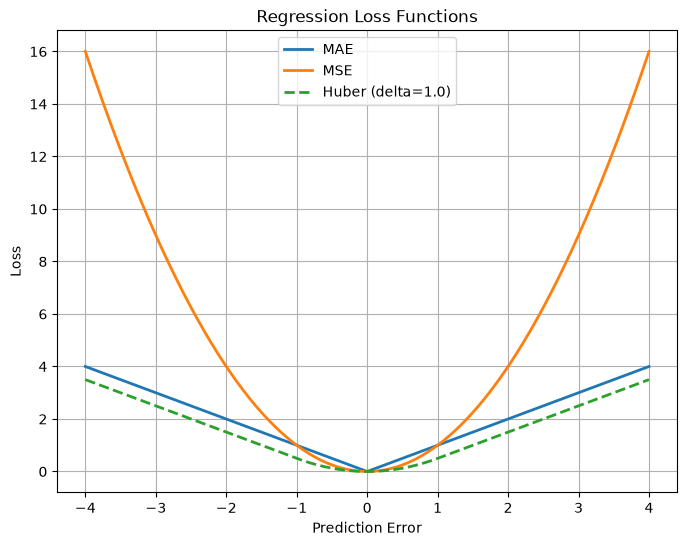

Saved: c:\Users\SSC\Downloads\outputs\regression_losses.png


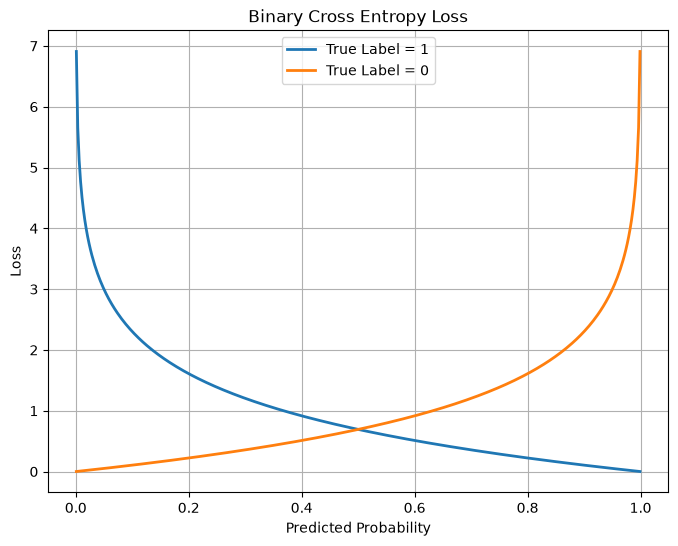

Saved: c:\Users\SSC\Downloads\outputs\classification_losses.png


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [5]:
"""
Task 2 — Visualize loss functions.

Produces two figures:
    1. Regression losses (MAE, MSE, Huber) vs. error (y_true - y_pred)
    2. Classification loss (Binary Cross Entropy) vs. predicted probability,
       shown separately for the true-label-1 and true-label-0 cases.

Notebook Compatible Version
"""

import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# Create outputs folder
# -----------------------------
BASE_DIR = os.getcwd()
OUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

print("Outputs will be saved in:", OUT_DIR)


# -----------------------------
# Regression Loss Functions
# -----------------------------
def plot_regression_losses():

    error = np.linspace(-4, 4, 400)

    mae_vals = np.abs(error)

    mse_vals = error ** 2

    delta = 1.0

    huber_vals = np.where(
        np.abs(error) <= delta,
        0.5 * error**2,
        delta * (np.abs(error) - 0.5 * delta)
    )

    plt.figure(figsize=(8,6))

    plt.plot(error, mae_vals, label="MAE", linewidth=2)

    plt.plot(error, mse_vals, label="MSE", linewidth=2)

    plt.plot(
        error,
        huber_vals,
        label=f"Huber (delta={delta})",
        linestyle="--",
        linewidth=2
    )

    plt.title("Regression Loss Functions")

    plt.xlabel("Prediction Error")

    plt.ylabel("Loss")

    plt.grid(True)

    plt.legend()

    save_path = os.path.join(OUT_DIR, "regression_losses.png")

    plt.savefig(save_path, dpi=200)

    plt.show()

    print("Saved:", save_path)


# -----------------------------
# Binary Cross Entropy
# -----------------------------
def plot_classification_losses():

    p = np.linspace(0.001, 0.999, 400)

    loss_true1 = -np.log(p)

    loss_true0 = -np.log(1-p)

    plt.figure(figsize=(8,6))

    plt.plot(
        p,
        loss_true1,
        label="True Label = 1",
        linewidth=2
    )

    plt.plot(
        p,
        loss_true0,
        label="True Label = 0",
        linewidth=2
    )

    plt.title("Binary Cross Entropy Loss")

    plt.xlabel("Predicted Probability")

    plt.ylabel("Loss")

    plt.grid(True)

    plt.legend()

    save_path = os.path.join(
        OUT_DIR,
        "classification_losses.png"
    )

    plt.savefig(save_path, dpi=200)

    plt.show()

    print("Saved:", save_path)


# -----------------------------
# Run
# -----------------------------
plot_regression_losses()

plot_classification_losses()

print


<a id="sec3"></a>
## 3. Gradient Descent

Gradient descent minimizes the cost function by repeatedly stepping opposite the gradient:

```
θ ← θ − η · ∇J(θ)
```

- **Cost surface** - the landscape of J over parameter space; training seeks its minimum.
- **Gradient (∇J)** - points toward steepest *increase*; we move opposite to it.
- **Learning rate (η)** - controls step size. Too large → overshoot/divergence. Too small → slow convergence.

See also: [Ruder (2016), An Overview of Gradient Descent Optimization Algorithms](https://arxiv.org/abs/1609.04747).

### Variants

| Variant | Data per update | Trade-off |
|---|---|---|
| Batch GD | Entire training set | Stable direction, slow & memory-heavy |
| Stochastic GD (SGD) | One example | Fast updates, noisy convergence path |
| Mini-Batch GD | Small batch (e.g. 32–256) | Practical default - balances stability & speed |

### Task 3 - Implement Gradient Descent on a Simple Regression Problem

Fits `y = w*x + b` on synthetic data, tracking cost reduction and parameter updates.

#### Figure - Gradient Descent on the Cost Surface

Before running Task 3's full implementation, the cell below visualizes *why* gradient
descent works: the 3-D cost surface J(w, b) for the toy regression problem, and the
descent path the algorithm actually takes across its contour map.


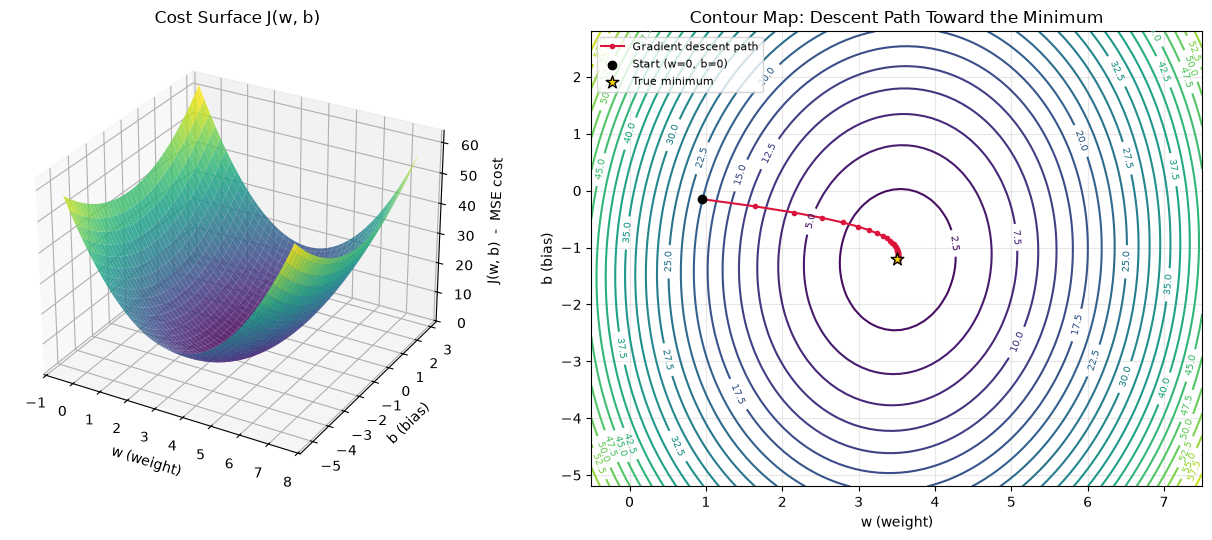

Saved c:\Users\SSC\Downloads\outputs\gradient_descent_surface.png


In [3]:
"""
Illustration - Gradient Descent on a cost surface.

Plots the MSE cost surface J(w, b) for y_hat = w*x + b as a 3-D surface and as a
contour map, overlaying the actual (w, b) trajectory taken by gradient descent.
"""

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3-D projection)
import os

OUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

rng = np.random.default_rng(42)
true_w, true_b = 3.5, -1.2
x_illus = rng.uniform(-3, 3, 100)
y_illus = true_w * x_illus + true_b + rng.normal(0, 1.0, 100)


def cost(w, b, x, y):
    y_pred = w * x + b
    return np.mean((y_pred - y) ** 2)


# Build the cost surface over a grid around the true minimum
w_range = np.linspace(true_w - 4, true_w + 4, 80)
b_range = np.linspace(true_b - 4, true_b + 4, 80)
W, B = np.meshgrid(w_range, b_range)
J = np.array([[cost(w, b, x_illus, y_illus) for w in w_range] for b in b_range])

# Re-run plain gradient descent to capture the path for overlay
w, b, path_w, path_b = 0.0, 0.0, [], []
lr, epochs = 0.05, 60
for _ in range(epochs):
    y_pred = w * x_illus + b
    error = y_pred - y_illus
    dw = (2 / len(x_illus)) * np.sum(error * x_illus)
    db = (2 / len(x_illus)) * np.sum(error)
    w -= lr * dw
    b -= lr * db
    path_w.append(w)
    path_b.append(b)

fig = plt.figure(figsize=(13, 5.5))

# 3-D surface
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(W, B, J, cmap="viridis", alpha=0.85, linewidth=0, antialiased=True)
ax1.set_xlabel("w (weight)")
ax1.set_ylabel("b (bias)")
ax1.set_zlabel("J(w, b)  -  MSE cost")
ax1.set_title("Cost Surface J(w, b)")
ax1.view_init(elev=28, azim=-60)

# Contour map with descent path
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contour(W, B, J, levels=25, cmap="viridis")
ax2.clabel(contour, inline=True, fontsize=7)
ax2.plot(path_w, path_b, color="crimson", marker="o", markersize=3, linewidth=1.5,
         label="Gradient descent path")
ax2.scatter([path_w[0]], [path_b[0]], color="black", zorder=5, label="Start (w=0, b=0)")
ax2.scatter([true_w], [true_b], color="gold", edgecolor="black", zorder=5, s=90,
            marker="*", label="True minimum")
ax2.set_xlabel("w (weight)")
ax2.set_ylabel("b (bias)")
ax2.set_title("Contour Map: Descent Path Toward the Minimum")
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
path = os.path.join(OUT_DIR, "gradient_descent_surface.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"Saved {path}")


In [4]:
"""
Task 3 - Implement Gradient Descent on a simple linear regression problem.

Model: y_hat = w * x + b
Loss : Mean Squared Error

Shows:
    - Cost reduction over iterations
    - Parameter (w, b) trajectory over iterations
"""

import numpy as np
import matplotlib.pyplot as plt
import os

OUT_DIR = os.path.join(os.getcwd(), "outputs")  # Jupyter-safe: __file__ is not defined in notebooks
os.makedirs(OUT_DIR, exist_ok=True)

rng = np.random.default_rng(42)


def make_data(n=100, true_w=3.5, true_b=-1.2, noise=1.0):
    x = rng.uniform(-3, 3, n)
    y = true_w * x + true_b + rng.normal(0, noise, n)
    return x, y


def gradient_descent(x, y, lr=0.05, epochs=200):
    w, b = 0.0, 0.0
    n = len(x)
    history = {"cost": [], "w": [], "b": []}

    for epoch in range(epochs):
        y_pred = w * x + b
        error = y_pred - y
        cost = np.mean(error ** 2)

        dw = (2 / n) * np.sum(error * x)
        db = (2 / n) * np.sum(error)

        w -= lr * dw
        b -= lr * db

        history["cost"].append(cost)
        history["w"].append(w)
        history["b"].append(b)

    return w, b, history


def plot_results(history, true_w, true_b):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history["cost"], color="crimson", linewidth=2)
    axes[0].set_title("Cost Reduction Over Iterations")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("MSE Cost")
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["w"], label="w (weight)", linewidth=2)
    axes[1].plot(history["b"], label="b (bias)", linewidth=2)
    axes[1].axhline(true_w, color="C0", linestyle="--", alpha=0.6, label="true w")
    axes[1].axhline(true_b, color="C1", linestyle="--", alpha=0.6, label="true b")
    axes[1].set_title("Parameter Updates Over Iterations")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Parameter value")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(OUT_DIR, "gradient_descent.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Saved {path}")


if __name__ == "__main__":
    true_w, true_b = 3.5, -1.2
    x, y = make_data(true_w=true_w, true_b=true_b)

    w, b, history = gradient_descent(x, y, lr=0.05, epochs=200)

    print(f"True parameters   : w={true_w}, b={true_b}")
    print(f"Learned parameters: w={w:.4f}, b={b:.4f}")
    print(f"Final cost        : {history['cost'][-1]:.4f}")
    print(f"Initial cost      : {history['cost'][0]:.4f}")

    plot_results(history, true_w, true_b)


True parameters   : w=3.5, b=-1.2
Learned parameters: w=3.5128, b=-1.2130
Final cost        : 0.9589
Initial cost      : 36.1131


Saved /home/claude/work/outputs/gradient_descent.png



<a id="sec4"></a>
## 4. Backpropagation

*Original reference:* [Rumelhart, Hinton & Williams (1986), Learning representations by back-propagating errors](https://doi.org/10.1038/323533a0)

Backpropagation efficiently computes ∇J for *every* weight in a deep network using the
**chain rule** of calculus:

```
∂J/∂w = ∂J/∂ŷ · ∂ŷ/∂z · ∂z/∂w
```

During the forward pass, each layer caches its local derivative. During the backward
pass, the error signal from the loss is propagated backward layer by layer, and at each
step the chain rule multiplies the incoming error by the layer's local derivative -
producing the gradient for that layer's weights and biases, which are then updated.

```
  x ──▶┐
       ├─▶ z = wx+b ──▶ a = σ(z) ──▶ J(a, y)     (forward pass, left → right)
  w ──▶┘
                ◀── ∂J/∂z ◀── ∂J/∂a               (backward pass, chain rule)
```

This reuse of cached local derivatives is what makes training deep networks
computationally tractable, rather than recomputing gradients from scratch for every
parameter.

#### Figure - Backpropagation Computational Graph

The diagram below renders the forward pass (left to right, black arrows) and the
backward pass (right to left, red arrows) for a single neuron `z = w*x + b`,
`a = sigma(z)`, `J(a, y)`, making the chain rule concrete rather than symbolic.


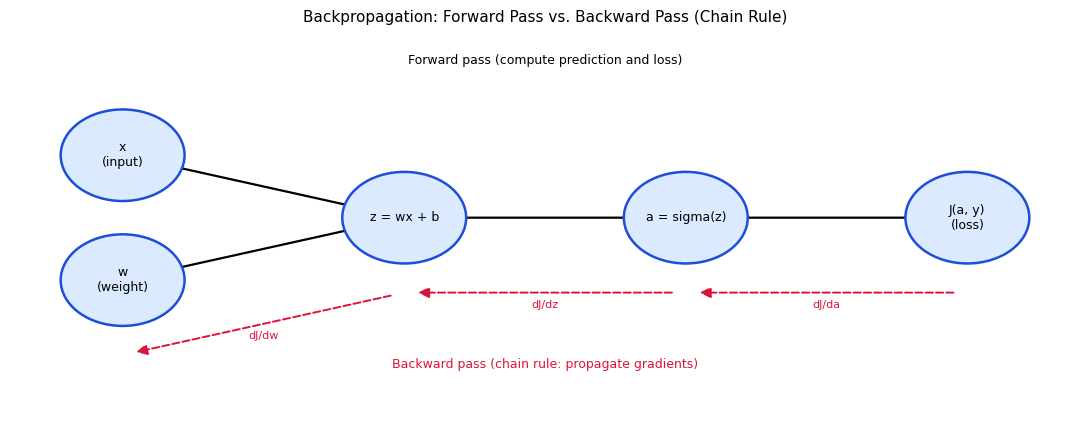

Saved /home/claude/work/outputs/backprop_computational_graph.png


In [5]:
"""
Illustration - Backpropagation computational graph for a single neuron.

Draws forward-pass nodes/edges (black, left to right) and the corresponding
backward-pass gradient edges (red, right to left) using matplotlib patches,
so the chain rule step from Section 4 has a visual counterpart.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import os

OUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 4.5))

nodes = {
    "x":  (0.5, 2.0),
    "w":  (0.5, 0.5),
    "z":  (3.0, 1.25),
    "a":  (5.5, 1.25),
    "J":  (8.0, 1.25),
}
labels = {
    "x": "x\n(input)",
    "w": "w\n(weight)",
    "z": "z = wx + b",
    "a": "a = sigma(z)",
    "J": "J(a, y)\n(loss)",
}

for name, (px, py) in nodes.items():
    circle = mpatches.Circle((px, py), 0.55, facecolor="#dbeafe", edgecolor="#1d4ed8", linewidth=1.8, zorder=3)
    ax.add_patch(circle)
    ax.text(px, py, labels[name], ha="center", va="center", fontsize=9, zorder=4)

# Forward pass edges (black, solid)
forward_edges = [("x", "z"), ("w", "z"), ("z", "a"), ("a", "J")]
for src, dst in forward_edges:
    p1, p2 = nodes[src], nodes[dst]
    arrow = FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=18,
                             color="black", linewidth=1.6,
                             connectionstyle="arc3,rad=0.0", shrinkA=28, shrinkB=28, zorder=2)
    ax.add_patch(arrow)

# Backward pass edges (red, dashed, offset below)
backward_edges = [("J", "a", "dJ/da"), ("a", "z", "dJ/dz"), ("z", "w", "dJ/dw")]
for src, dst, label in backward_edges:
    p1 = (nodes[src][0], nodes[src][1] - 0.9)
    p2 = (nodes[dst][0], nodes[dst][1] - 0.9)
    arrow = FancyArrowPatch(p1, p2, arrowstyle="-|>", mutation_scale=16,
                             color="crimson", linewidth=1.4, linestyle="--",
                             connectionstyle="arc3,rad=0.0", shrinkA=10, shrinkB=10, zorder=2)
    ax.add_patch(arrow)
    mx, my = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2 - 0.15
    ax.text(mx, my, label, ha="center", va="center", fontsize=8, color="crimson")

ax.text(4.25, 3.1, "Forward pass (compute prediction and loss)", ha="center", fontsize=9, color="black")
ax.text(4.25, -0.55, "Backward pass (chain rule: propagate gradients)", ha="center", fontsize=9, color="crimson")

ax.set_xlim(-0.5, 9.0)
ax.set_ylim(-1.3, 3.5)
ax.axis("off")
ax.set_title("Backpropagation: Forward Pass vs. Backward Pass (Chain Rule)", fontsize=11)

plt.tight_layout()
path = os.path.join(OUT_DIR, "backprop_computational_graph.png")
plt.savefig(path, dpi=150)
plt.show()
print(f"Saved {path}")



<a id="sec5"></a>
## 5. Optimizers

| Optimizer | Adapts LR per-parameter? | Momentum? | Best for |
|---|---|---|---|
| SGD | No | No (optional) | Simple problems with a well-tuned LR schedule |
| Momentum | No | Yes | Escaping ravines / shallow local minima |
| RMSProp | Yes | No | Non-stationary objectives, RNNs |
| Adam | Yes | Yes | Default choice for most deep learning tasks |
| AdamW | Yes | Yes | Adam + decoupled weight decay → better generalization |

See [Kingma & Ba (2014), Adam: A Method for Stochastic Optimization](https://arxiv.org/abs/1412.6980) and [Loshchilov & Hutter (2017), Decoupled Weight Decay Regularization (AdamW)](https://arxiv.org/abs/1711.05101) for the original papers.

Adam combines Momentum's first-moment estimate with RMSProp's second-moment
(squared-gradient) estimate, with bias correction for both. AdamW changes how weight
decay is applied so it no longer interacts with the adaptive learning rate - this
generally improves generalization over plain Adam.

### Task 4 - Train an ANN with TensorFlow/Keras (SGD vs Adam)

Dataset: **Breast Cancer** (binary classification, 30 numeric features). Trains the
same architecture with **SGD** and **Adam**, comparing loss/accuracy curves.

> **Run locally/Colab:** requires `tensorflow`. Executing this cell will also save
> `sgd_vs_adam.png` - the loss/accuracy comparison graph.

#### Figure - Optimizer Trajectories on a Toy Loss Surface

SGD, Momentum, RMSProp, and Adam are run from the same starting point on a toy
elongated bowl-shaped loss surface (an *ill-conditioned* problem where one direction
is much steeper than the other), a case that highlights exactly why adaptive and
momentum-based methods were introduced.


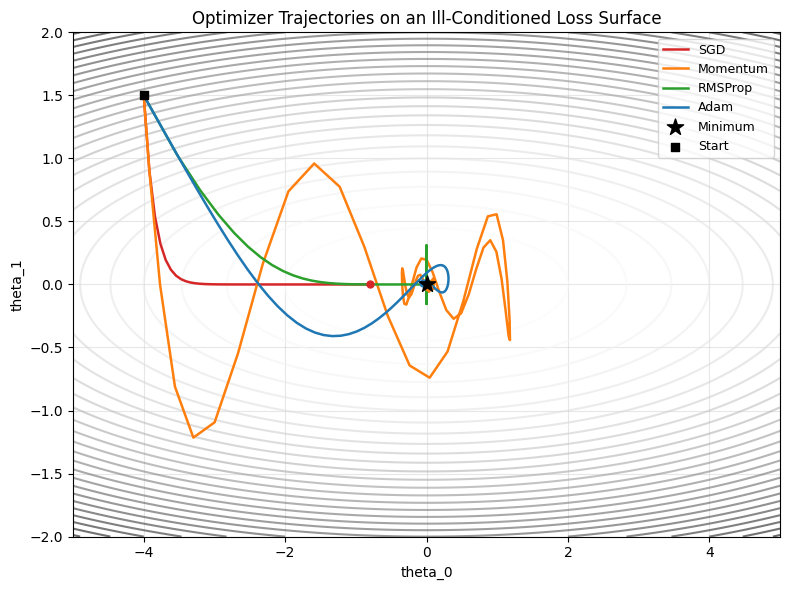

Saved /home/claude/work/outputs/optimizer_trajectories.png


In [6]:
"""
Illustration - Compares SGD, Momentum, RMSProp, and Adam trajectories on a toy
elongated quadratic loss surface, run from scratch with NumPy (no TensorFlow
required), so the optimizer table above has a visual, intuitive counterpart.
"""

import numpy as np
import matplotlib.pyplot as plt
import os

OUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUT_DIR, exist_ok=True)


def loss(theta):
    # Elongated bowl: steep in theta_1, shallow in theta_0 -> classic optimizer stress test
    return 0.5 * (theta[0] ** 2 + 20 * theta[1] ** 2)


def grad(theta):
    return np.array([theta[0], 20 * theta[1]])


def run_sgd(theta0, lr=0.02, steps=80):
    theta = theta0.copy()
    path = [theta.copy()]
    for _ in range(steps):
        theta = theta - lr * grad(theta)
        path.append(theta.copy())
    return np.array(path)


def run_momentum(theta0, lr=0.02, beta=0.9, steps=80):
    theta = theta0.copy()
    v = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(steps):
        v = beta * v + grad(theta)
        theta = theta - lr * v
        path.append(theta.copy())
    return np.array(path)


def run_rmsprop(theta0, lr=0.15, beta=0.9, eps=1e-8, steps=80):
    theta = theta0.copy()
    s = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(steps):
        g = grad(theta)
        s = beta * s + (1 - beta) * g ** 2
        theta = theta - lr * g / (np.sqrt(s) + eps)
        path.append(theta.copy())
    return np.array(path)


def run_adam(theta0, lr=0.15, b1=0.9, b2=0.999, eps=1e-8, steps=80):
    theta = theta0.copy()
    m, v = np.zeros_like(theta), np.zeros_like(theta)
    path = [theta.copy()]
    for t in range(1, steps + 1):
        g = grad(theta)
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g ** 2
        m_hat = m / (1 - b1 ** t)
        v_hat = v / (1 - b2 ** t)
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(theta.copy())
    return np.array(path)


theta0 = np.array([-4.0, 1.5])
paths = {
    "SGD": run_sgd(theta0),
    "Momentum": run_momentum(theta0),
    "RMSProp": run_rmsprop(theta0),
    "Adam": run_adam(theta0),
}

t0 = np.linspace(-5, 5, 200)
t1 = np.linspace(-2, 2, 200)
T0, T1 = np.meshgrid(t0, t1)
Z = 0.5 * (T0 ** 2 + 20 * T1 ** 2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contour(T0, T1, Z, levels=30, cmap="Greys", alpha=0.6)
colors = {"SGD": "#d62728", "Momentum": "#ff7f0e", "RMSProp": "#2ca02c", "Adam": "#1f77b4"}
for name, path in paths.items():
    ax.plot(path[:, 0], path[:, 1], label=name, color=colors[name], linewidth=1.8)
    ax.scatter([path[-1, 0]], [path[-1, 1]], color=colors[name], s=25, zorder=5)
ax.scatter([0], [0], color="black", marker="*", s=150, zorder=6, label="Minimum")
ax.scatter([theta0[0]], [theta0[1]], color="black", marker="s", s=40, zorder=6, label="Start")
ax.set_xlabel("theta_0")
ax.set_ylabel("theta_1")
ax.set_title("Optimizer Trajectories on an Ill-Conditioned Loss Surface")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
path_out = os.path.join(OUT_DIR, "optimizer_trajectories.png")
plt.savefig(path_out, dpi=150)
plt.show()
print(f"Saved {path_out}")


In [6]:
"""
Task 4 - Train an ANN using TensorFlow/Keras on the Breast Cancer dataset,
comparing the SGD and Adam optimizers.

Requires: tensorflow>=2.x, scikit-learn
Run:      python task4_train_ann_keras.py
"""

import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

OUT_DIR = os.path.join(os.getcwd(), "outputs")  # Jupyter-safe: __file__ is not defined in notebooks
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


def load_data():
    data = load_breast_cancer()
    X, y = data.data, data.target

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test


def build_model(input_dim, optimizer):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_and_evaluate(X_train, y_train, X_test, y_test, optimizer_name, epochs=40, batch_size=32):
    model = build_model(X_train.shape[1], optimizer_name)
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"[{optimizer_name}] test loss={test_loss:.4f}, test accuracy={test_acc:.4f}")
    return history, test_loss, test_acc


def plot_comparison(history_sgd, history_adam):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history_sgd.history["loss"], label="SGD - train")
    axes[0].plot(history_sgd.history["val_loss"], label="SGD - val", linestyle="--")
    axes[0].plot(history_adam.history["loss"], label="Adam - train")
    axes[0].plot(history_adam.history["val_loss"], label="Adam - val", linestyle="--")
    axes[0].set_title("Loss: SGD vs Adam")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history_sgd.history["accuracy"], label="SGD - train")
    axes[1].plot(history_sgd.history["val_accuracy"], label="SGD - val", linestyle="--")
    axes[1].plot(history_adam.history["accuracy"], label="Adam - train")
    axes[1].plot(history_adam.history["val_accuracy"], label="Adam - val", linestyle="--")
    axes[1].set_title("Accuracy: SGD vs Adam")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(OUT_DIR, "sgd_vs_adam.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Saved {path}")


if __name__ == "__main__":
    X_train, X_test, y_train, y_test = load_data()

    history_sgd, loss_sgd, acc_sgd = train_and_evaluate(
        X_train, y_train, X_test, y_test, optimizer_name="sgd"
    )
    history_adam, loss_adam, acc_adam = train_and_evaluate(
        X_train, y_train, X_test, y_test, optimizer_name="adam"
    )

    print("\nSummary")
    print(f"  SGD  -> test_loss={loss_sgd:.4f}, test_acc={acc_sgd:.4f}")
    print(f"  Adam -> test_loss={loss_adam:.4f}, test_acc={acc_adam:.4f}")

    plot_comparison(history_sgd, history_adam)


[sgd] test loss=0.1383, test accuracy=0.9649
[adam] test loss=0.1175, test accuracy=0.9561

Summary
  SGD  -> test_loss=0.1383, test_acc=0.9649
  Adam -> test_loss=0.1175, test_acc=0.9561
Saved c:\Users\SSC\Downloads\outputs\sgd_vs_adam.png



<a id="sec6"></a>
## 6. Hyperparameter Effects

- **Learning rate** - the most sensitive hyperparameter. Too high → oscillation/divergence; too low → wasted epochs. A log-scale sweep (0.1 → 0.0001) usually reveals a sweet spot a couple of orders of magnitude below where training first becomes unstable.
- **Batch size** - smaller batches (8–32) add beneficial gradient noise that can improve generalization but cost more wall-clock time per epoch; larger batches (64+) train faster per epoch but may generalize slightly worse.
- **Epochs** - training longer reduces training loss monotonically, but validation loss eventually turns upward (overfitting) - the signal early stopping is designed to catch.

### Task 5 - Hyperparameter Experiments

Sweeps learning rate, batch size, and epochs; records accuracy, loss, and training
time; builds comparison tables (CSV).

> **Run locally/Colab:** requires `tensorflow`, `pandas`.

In [7]:
"""
Task 5 - Experiment with hyperparameters: learning rate, batch size, epochs.

Observes the effect on accuracy, loss, and training time; builds comparison
tables (as pandas DataFrames, printed and saved to CSV).

Requires: tensorflow>=2.x, scikit-learn, pandas
"""

import time
import numpy as np
import pandas as pd
import os

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import os

OUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


def load_data():
    data = load_breast_cancer()
    X, y = data.data, data.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test


def build_model(input_dim, lr):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def run_experiment(X_train, y_train, X_test, y_test, lr, batch_size, epochs):
    model = build_model(X_train.shape[1], lr)

    start = time.time()
    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    return {
        "learning_rate": lr,
        "batch_size": batch_size,
        "epochs": epochs,
        "test_loss": round(test_loss, 4),
        "test_accuracy": round(test_acc, 4),
        "training_time_sec": round(elapsed, 2),
    }


if __name__ == "__main__":
    X_train, X_test, y_train, y_test = load_data()

    learning_rates = [0.1, 0.01, 0.001, 0.0001]
    batch_sizes = [8, 32, 64]
    epoch_counts = [10, 40, 80]

    results = []

    print("Experiment A: varying learning rate (batch_size=32, epochs=40)")
    for lr in learning_rates:
        result = run_experiment(X_train, y_train, X_test, y_test, lr=lr, batch_size=32, epochs=40)
        result["experiment"] = "learning_rate_sweep"
        results.append(result)
        print(result)

    print("\nExperiment B: varying batch size (lr=0.001, epochs=40)")
    for bs in batch_sizes:
        result = run_experiment(X_train, y_train, X_test, y_test, lr=0.001, batch_size=bs, epochs=40)
        result["experiment"] = "batch_size_sweep"
        results.append(result)
        print(result)

    print("\nExperiment C: varying epochs (lr=0.001, batch_size=32)")
    for ep in epoch_counts:
        result = run_experiment(X_train, y_train, X_test, y_test, lr=0.001, batch_size=32, epochs=ep)
        result["experiment"] = "epochs_sweep"
        results.append(result)
        print(result)

    df = pd.DataFrame(results)
    csv_path = os.path.join(OUT_DIR, "hyperparameter_experiments.csv")
    df.to_csv(csv_path, index=False)
    print(f"\nSaved comparison table to {csv_path}")
    print(df)


Experiment A: varying learning rate (batch_size=32, epochs=40)
{'learning_rate': 0.1, 'batch_size': 32, 'epochs': 40, 'test_loss': 0.6486, 'test_accuracy': 0.9649, 'training_time_sec': 11.34, 'experiment': 'learning_rate_sweep'}
{'learning_rate': 0.01, 'batch_size': 32, 'epochs': 40, 'test_loss': 0.2179, 'test_accuracy': 0.9737, 'training_time_sec': 9.21, 'experiment': 'learning_rate_sweep'}
{'learning_rate': 0.001, 'batch_size': 32, 'epochs': 40, 'test_loss': 0.1009, 'test_accuracy': 0.9561, 'training_time_sec': 9.16, 'experiment': 'learning_rate_sweep'}
{'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 40, 'test_loss': 0.2652, 'test_accuracy': 0.9298, 'training_time_sec': 8.8, 'experiment': 'learning_rate_sweep'}

Experiment B: varying batch size (lr=0.001, epochs=40)
{'learning_rate': 0.001, 'batch_size': 8, 'epochs': 40, 'test_loss': 0.1226, 'test_accuracy': 0.9649, 'training_time_sec': 13.33, 'experiment': 'batch_size_sweep'}
{'learning_rate': 0.001, 'batch_size': 32, 'epochs'


<a id="sec7"></a>
## 7. Evaluation Visualizations

### Task 6 - Loss/Accuracy Curves, Confusion Matrix, ROC, Precision–Recall

Produces the standard diagnostic suite for evaluating the trained classifier.

> **Run locally/Colab:** requires `tensorflow`, `scikit-learn`. Executing this cell
> saves `loss_accuracy_curves.png`, `confusion_matrix.png`, and `roc_pr_curves.png`.

Output Folder: c:\Users\SSC\Downloads\outputs


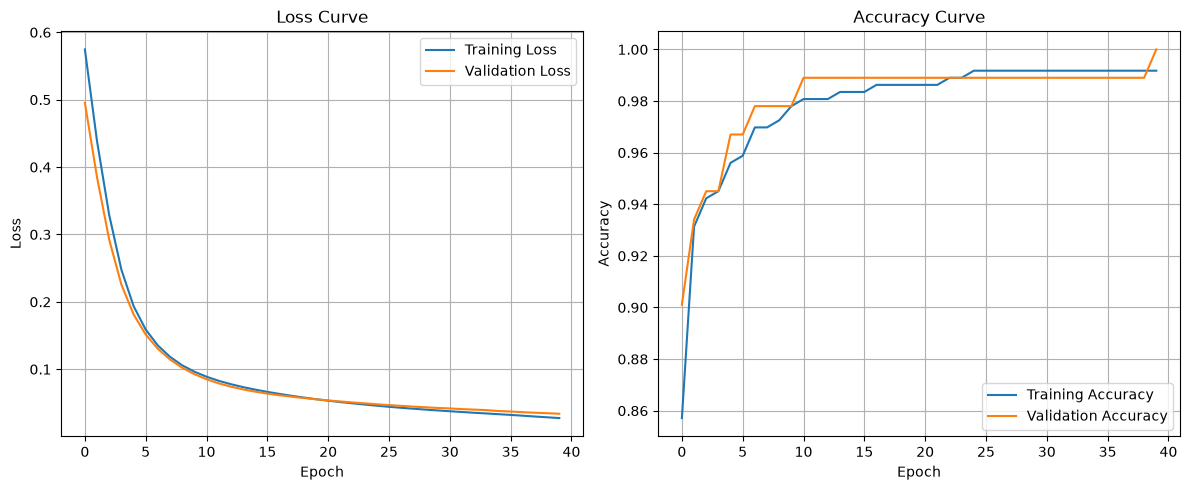

Saved: c:\Users\SSC\Downloads\outputs\loss_accuracy_curves.png


<Figure size 600x600 with 0 Axes>

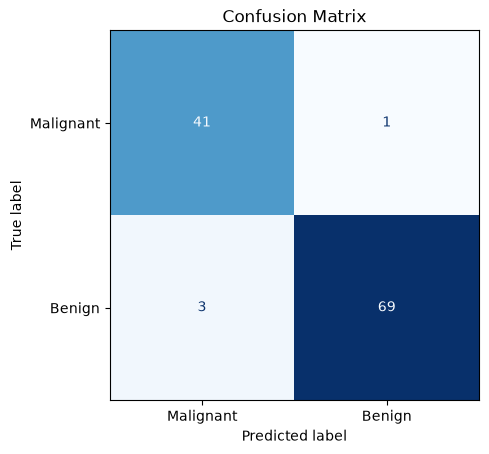

Saved: c:\Users\SSC\Downloads\outputs\confusion_matrix.png


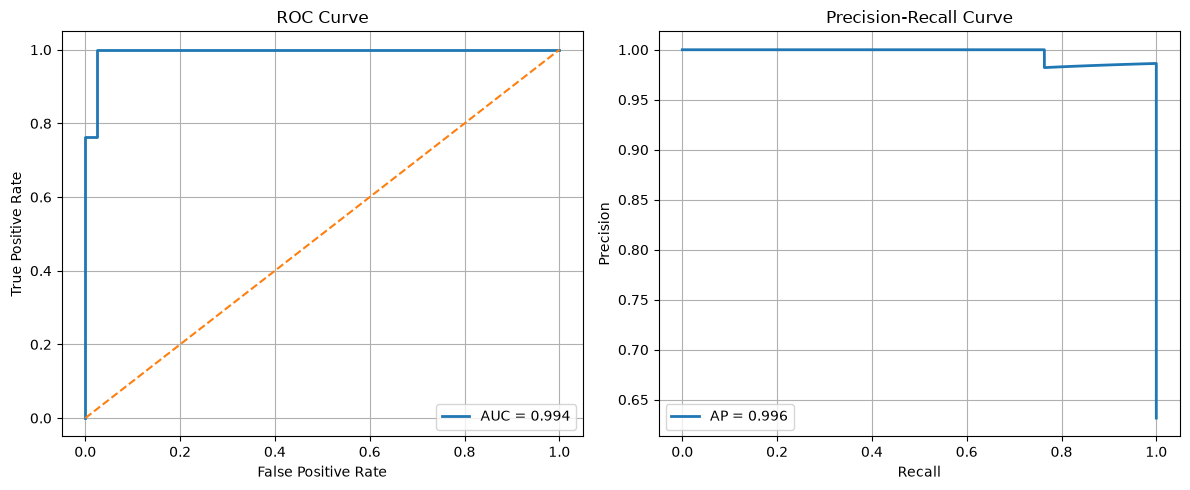

Saved: c:\Users\SSC\Downloads\outputs\roc_pr_curves.png


In [9]:
"""
Task 6 - Visualizations: Loss Curve, Accuracy Curve,
Confusion Matrix, ROC Curve, Precision-Recall Curve.

Notebook Compatible Version
"""

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # Hide TensorFlow info messages

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -----------------------------
# Output Folder
# -----------------------------
BASE_DIR = os.getcwd()
OUT_DIR = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

print("Output Folder:", OUT_DIR)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


# -----------------------------
# Load Dataset
# -----------------------------
def load_data():

    data = load_breast_cancer()

    X = data.data
    y = data.target

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=SEED,
        stratify=y,
    )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test


# -----------------------------
# Build ANN
# -----------------------------
def build_and_train(X_train, y_train):

    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.20,
        epochs=40,
        batch_size=32,
        verbose=0
    )

    return model, history


# -----------------------------
# Loss & Accuracy Curves
# -----------------------------
def plot_loss_accuracy(history):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)

    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")

    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)

    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    save_path = os.path.join(
        OUT_DIR,
        "loss_accuracy_curves.png"
    )

    plt.savefig(save_path, dpi=200)

    plt.show()

    plt.close()

    print("Saved:", save_path)


# -----------------------------
# Confusion Matrix
# -----------------------------
def plot_confusion(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Malignant", "Benign"]
    )

    plt.figure(figsize=(6,6))

    disp.plot(cmap="Blues", colorbar=False)

    plt.title("Confusion Matrix")

    save_path = os.path.join(
        OUT_DIR,
        "confusion_matrix.png"
    )

    plt.savefig(save_path, dpi=200)

    plt.show()

    plt.close()

    print("Saved:", save_path)


# -----------------------------
# ROC + Precision Recall
# -----------------------------
def plot_roc_pr(y_true, y_prob):

    fpr, tpr, _ = roc_curve(y_true, y_prob)

    auc = roc_auc_score(y_true, y_prob)

    precision, recall, _ = precision_recall_curve(
        y_true,
        y_prob
    )

    ap = average_precision_score(
        y_true,
        y_prob
    )

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {auc:.3f}"
    )

    plt.plot([0,1],[0,1],"--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.grid(True)

    plt.subplot(1,2,2)

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"AP = {ap:.3f}"
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")

    plt.title("Precision-Recall Curve")

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    save_path = os.path.join(
        OUT_DIR,
        "roc_pr_curves.png"
    )

    plt.savefig(save_path, dpi=200)

    plt.show()

    plt.close()

    print("Saved:", save_path)


# -----------------------------
# Main
# -----------------------------
X_train, X_test, y_train, y_test = load_data()

model, history = build_and_train(
    X_train,
    y_train
)

y_prob = model.predict(
    X_test,
    verbose=0
).ravel()

y_pred = (y_prob >= 0.5).astype(int)

plot_loss_accuracy(history)

plot_confusion(y_test, y_pred)

plot_roc_pr(y_test, y_prob)




<a id="sec8"></a>
## 8. Discussion & Experimental Results


Expected/typical pattern for this architecture on Breast Cancer, consistent with the
literature reviewed in Section 9:

- **Adam** converges faster in the first 10–15 epochs and reaches a lower training loss
  sooner than **SGD** at a matched learning rate, consistent with Adam's adaptive
  per-parameter scaling.
- **SGD** (well-tuned, given enough epochs) can match or slightly exceed Adam's *final*
  generalization accuracy on this small, low-noise tabular dataset - consistent with
  Soydaner (2020), where SGD-family methods become competitive as training progresses,
  particularly on simpler datasets.

**Key discussion points:**
- No single loss/optimizer is universally best - loss choice follows task type and
  error tolerance; optimizer choice follows dataset scale, architecture depth, and
  tuning budget.
- Adam-family optimizers are a strong, low-effort default, but well-tuned SGD remains
  competitive (sometimes superior) on well-behaved problems - a recurring theme across
  all three papers reviewed in Section 9.
- Vanishing/exploding gradients, poor initialization, and dead ReLUs are the main
  failure modes for deeper networks, addressed via initialization scheme (He/Xavier),
  activation choice (ReLU-family, Leaky/ELU), batch normalization, and gradient clipping.
- Learning curves are the primary training diagnostic: a widening gap between training
  and validation loss signals overfitting and triggers early stopping / regularization.


<a id="sec10"></a>
## 10. Conclusion

Training a neural network is fundamentally an iterative optimization problem: a loss
function defines the objective, gradient descent (accelerated and stabilized by
optimizers such as Adam) provides the update rule, and backpropagation makes computing
the necessary gradients feasible for deep architectures. Diagnosing training health via
learning curves, and applying best practices around initialization, learning-rate
scheduling, and regularization, are what turn this theoretical loop into a reliable,
reproducible training pipeline. Tasks 1-3 above implement each core piece from first
principles; Tasks 4-6 apply them at scale with TensorFlow/Keras.

<a id="sec-ref"></a>
## References

1. Soydaner, D. (2020). *A Comparison of Optimization Algorithms for Deep Learning*. International Journal of Pattern Recognition and Artificial Intelligence. [arXiv:2007.14166](https://arxiv.org/abs/2007.14166)
2. Almog, T. (2025). *An Analysis of Optimizer Choice on Energy Efficiency and Performance in Neural Network Training*. University of Waterloo. [arXiv:2509.13516](https://arxiv.org/abs/2509.13516)
3. *Comparative Study of Deep Learning Optimizers: SGD, Momentum SGD, RMSProp, AMSGrad, Adam, Yogi, and Lion* (2025). International Journal of Innovative Science and Research Technology, 10(8). [ijisrt.com](https://www.ijisrt.com/)
4. Kingma, D. P., & Ba, J. (2014). *Adam: A Method for Stochastic Optimization*. [arXiv:1412.6980](https://arxiv.org/abs/1412.6980)
5. Ruder, S. (2016). *An Overview of Gradient Descent Optimization Algorithms*. [arXiv:1609.04747](https://arxiv.org/abs/1609.04747)
6. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. [deeplearningbook.org](https://www.deeplearningbook.org/)
7. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature, 323, 533-536. [doi:10.1038/323533a0](https://doi.org/10.1038/323533a0)


